# Plot all mimimum pressure tracks 

This creates a visual comparison for hurricane Paulette between MODIS and ICON.

Using levante python kernel "1 Python 3" (can be recreated from `../environment-standard.yml`)

In [1]:
#%matplotlib inline

import os, sys, glob
import pylab as plt
import numpy as np
import scipy.ndimage

import seaborn as sns
sns.set_context('talk')

import datetime
import xarray as xr
xr.set_options(keep_attrs=True)

from matplotlib.patches import Rectangle, Circle
import matplotlib.gridspec as gridspec

import tomli as tomllib  # fallback for older Python versions

# drawing onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

In [2]:
sys.path.append('../tools')
import timetools


## Arguments

In [3]:
smooth_reference_track = False

## Configurations

In [4]:
conf_path = '{HOME}/proj/2025-05_hurricane-centric-setup-tools/config/levante'.format(**os.environ)

conf_list = [f'{conf_path}/hurricane_config_width100km_reinit12h.toml',
             f'{conf_path}/hurricane_config_width100km_reinit24h.toml',
             f'{conf_path}/hurricane_config_width200km_reinit12h.toml',
             f'{conf_path}/hurricane_config_width200km_reinit24h.toml'
]


In [5]:
conf = {}
for config_file in conf_list:
    with open(config_file, "rb") as f:
        conf_base = os.path.basename( config_file )
        conf[conf_base] = tomllib.load(f)

## Data Input

### Functions

In [6]:
def all_track_filenames( c ):

    projectname = c['project']['name']
    width_config = c['project']['width_config']

    track_basedir = '/work/bb1376/data/icon/atlantic-cases/derived-data/tracks'
    
    trackdir_pattern = f'{track_basedir}'
    trackfile_pattern = f'{projectname}-{width_config}-segment??-????????T????Z-exp111_trajectories_pmin_DOM0?.nc'

   
    tracklist = sorted( glob.glob(f'{trackdir_pattern}/{trackfile_pattern}'))

    return tracklist
    

### Open Pmin Tracks

In [7]:
seg_tracks = {}

for conf_name in sorted( conf ):
    seg_tracks[conf_name] = {}

    trackfiles = all_track_filenames( conf[conf_name] )
    
    if len(trackfiles) == 0:
        continue
    else:
        for f in trackfiles:
            seg_tracks[conf_name][f] = xr.open_dataset( f )

### Open Best Fitting Reference Track 

In [8]:
track_dir = '/work/bb1376/data/icon/atlantic-cases/derived-data/tracks/'

trackfile = f'{track_dir}/ifces2-atlanXL-20200907-exp021-DOM02_paulette_best-fit.nc'


In [9]:
ref_track = xr.open_dataset( trackfile ).swap_dims({'index':'time'})

In [10]:
if smooth_reference_track:
    ref_track = ref_track[['longitude', 'latitude']].rolling( time=13, center=True).mean()

## Plotting 

In [11]:
def get_props_from_trackname( fname ):

    basename = os.path.splitext( os.path.basename( fname ))[0]

    _, _, _, sefname, date, suffix = basename.split('-')
    _, _, _, domname = suffix.split('_')

    idom = int( domname[-1] )
    iseg = int( sefname[-2:] )

    return iseg, idom

In [12]:
def plot_segment(fname, track, color = 'k', symbol = None, symbol_size = 20, line_style = '-'):


    lws = [4, 2, 1, ]
    
    iseg, idom = get_props_from_trackname( fname )

    x, y = track.lon, track.lat

    plt.plot( x, y, color = color, lw = lws[idom-1], ls = line_style)

    if symbol is not None:
        plt.plot( x[-1], y [-1], marker = symbol, color = color, ms = symbol_size, mec = 'w', mew = 3)
        
    
    return 

In [13]:
def plot_var(fname, vname, track, color = 'k', symbol = None, symbol_size = 20, scale = 1., line_style = '-'):


    lws = [4, 2, 1, ]
    
    iseg, idom = get_props_from_trackname( fname )

    t, v = track.time, track[vname]
    v = scale * v

    plt.plot( t, v, color = color, lw = lws[idom-1], ls = line_style)

    if symbol is not None:
        plt.plot( t[-1], v[-1], marker = symbol, color = color, ms = symbol_size, mec = 'w', mew = 2)

    return 

In [14]:
selected_set = 'not_all'

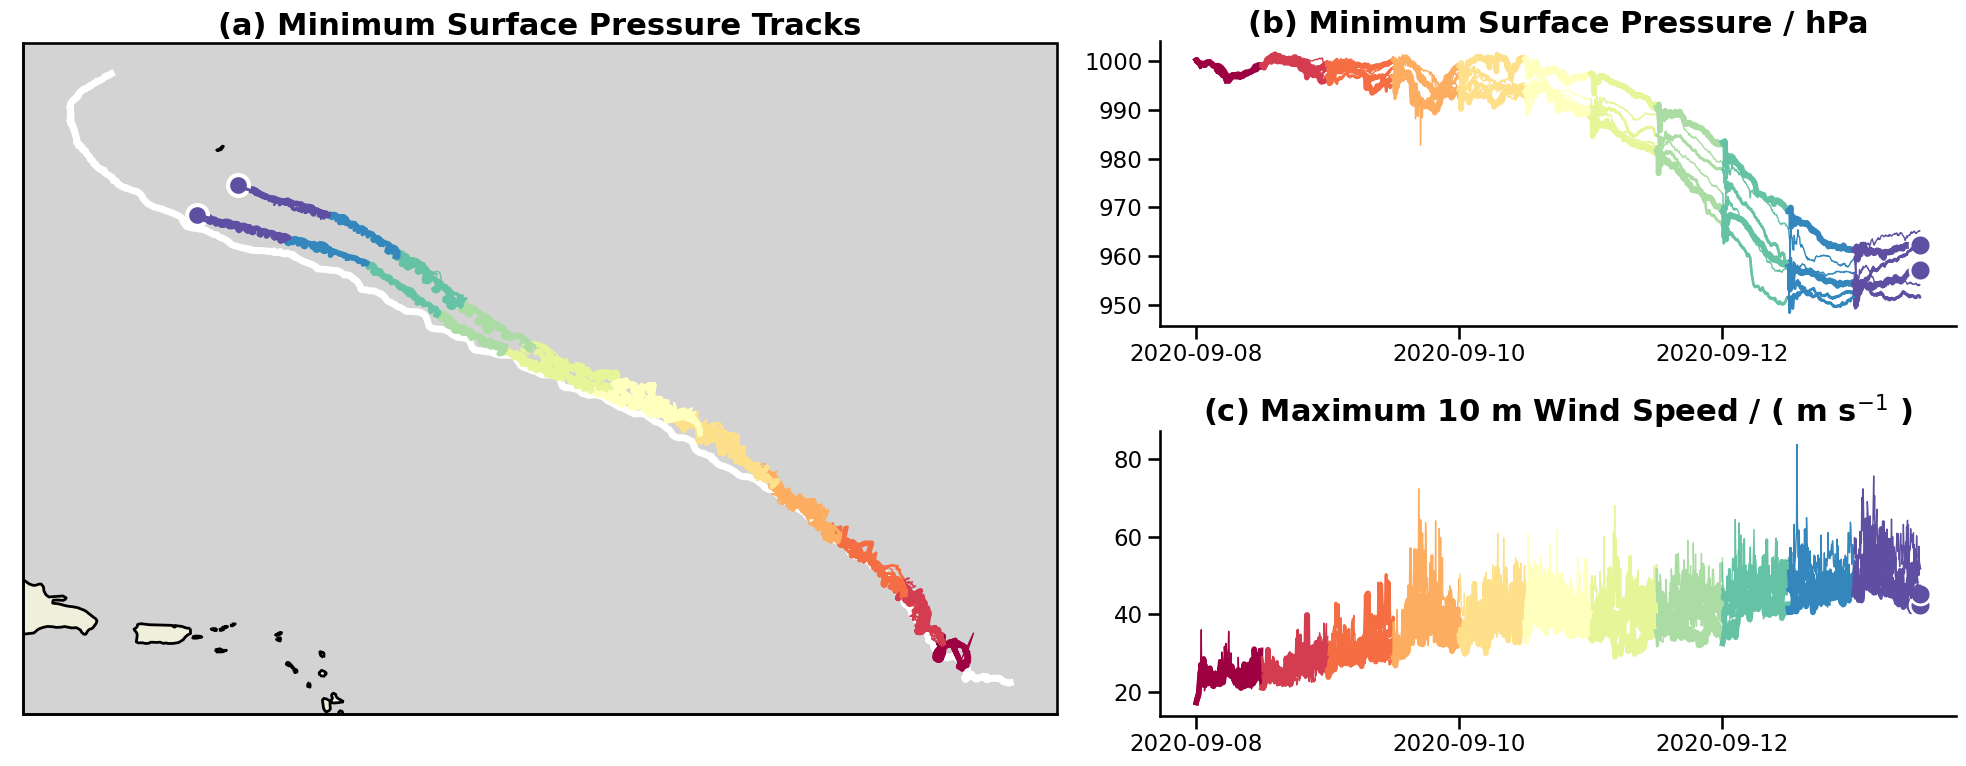

In [15]:
fig_combined = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.3, 1], height_ratios=[1, 1])
# 
ax_main = fig_combined.add_subplot(gs[:, 0], projection = ccrs.PlateCarree())
ax_top_right = fig_combined.add_subplot(gs[0, 1])
ax_bottom_right = fig_combined.add_subplot(gs[1, 1])


# this is our map projection
ax = plt.sca( ax_main)
ax = ax_main #plt.axes()
ax.add_feature(cfeature.LAND.with_scale('50m'))
ax.add_feature(cfeature.OCEAN.with_scale('50m'), color = 'lightgray')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth = 1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth = 2)
#ax.set_extent( (-5,25,42,58))


ax.plot(ref_track.longitude, ref_track.latitude, lw = 5, color = 'white')


if selected_set == 'all':
    symbols = ['o', 's', 'o', 's']
    symbol_sizes = [15, 15, 25, 25]
    line_styles = ['-', ]*4 #'--', '-.','._.']
    explist = ['hurricane_config_width100km_reinit12h.toml',
     'hurricane_config_width100km_reinit24h.toml',
     'hurricane_config_width200km_reinit12h.toml',
     'hurricane_config_width200km_reinit24h.toml']

else:
    symbols = ['o',]*2
    symbol_sizes = [15, 15,]
    line_styles = ['-', ]*2 #'--', '-.','._.']
    explist = ['hurricane_config_width100km_reinit12h.toml',
     'hurricane_config_width200km_reinit12h.toml',]

for ic, conf_name in enumerate( explist ):
    track_files = seg_tracks[conf_name].keys()
    nfiles = len(track_files)
    colors = list( plt.cm.Spectral(np.linspace(0, 1, nfiles//3)))
    
    i = 0
    for n, fname in enumerate( track_files ):

        if n == nfiles - 3:
            symbol = symbols[ic]
        else:
            symbol = None
    
        track = seg_tracks[conf_name][fname]

        kws = dict(color = colors[i], symbol = symbol, symbol_size = symbol_sizes[ic], line_style = line_styles[ic])
        plot_segment( fname, track, **kws )
    
        if np.mod(n+1, 3) == 0:
            i += 1
plt.title('(a) Minimum Surface Pressure Tracks', fontsize = 22, fontweight = 'bold')

a = ax_top_right
plt.sca( ax_top_right )


for ic, conf_name in enumerate(explist):
    track_files = seg_tracks[conf_name].keys()
    nfiles = len(track_files)
    
    colors = list( plt.cm.Spectral(np.linspace(0, 1, nfiles//3)))
    
    i = 0
    for n, fname in enumerate( track_files ):

        if n == nfiles - 3:
            symbol = symbols[ic]
        else:
            symbol = None
    
        track = seg_tracks[conf_name][fname]
        kws = dict(color = colors[i], symbol = symbol, symbol_size = symbol_sizes[ic], line_style = line_styles[ic], scale = 1e-2)
        plot_var( fname, 'ps_min', track, **kws)
    
        if np.mod(n+1, 3) == 0:            
            i += 1

xticks = a.get_xticks()[::2]
a.set_xticks( xticks )

plt.title('(b) Minimum Surface Pressure / hPa', fontsize = 22, fontweight = 'bold')
sns.despine()

#plt.savefig('../pics/pmin-tracks.png', dpi = 300)

a = ax_bottom_right
plt.sca( ax_bottom_right )

for ic, conf_name in enumerate( explist ):
    track_files = seg_tracks[conf_name].keys()
    nfiles = len(track_files)
    
    colors = list( plt.cm.Spectral(np.linspace(0, 1, nfiles//3)))
    
    i = 0
    for n, fname in enumerate( track_files ):

        if n == nfiles - 3:
            symbol = symbols[ic]
        else:
            symbol = None
    
        track = seg_tracks[conf_name][fname]
        kws = dict(color = colors[i], symbol = symbol, symbol_size = symbol_sizes[ic], line_style = line_styles[ic])
        plot_var( fname, 'max_speed', track, **kws)
    
        if np.mod(n+1, 3) == 0:            
            i += 1

xticks = a.get_xticks()[::2]
a.set_xticks( xticks )

plt.title('(c) Maximum 10 m Wind Speed / ( m s${}^{-1}$ )', fontsize = 22, fontweight = 'bold')
plt.tight_layout()

plt.savefig('../pics/tracks_and_min-max-evolution.png', dpi = 300)